# **PRAKTIKUM PERTEMUAN 7 DATA SCIENCE**

Nama : Bintang Hanifatul Manunggal

Nim   :  250401020095

### **Langkah 1: Generate dan Eksplorasi Dataset**

Shape: (300, 4)
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


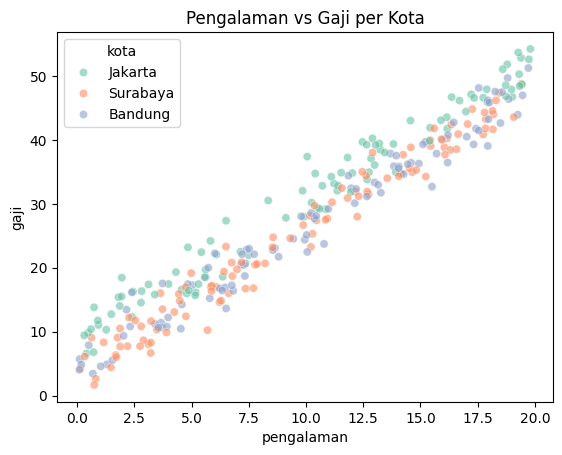

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generate dataset sintetis
np.random.seed(42)
n = 300

pengalaman = np.random.uniform(0, 20, n)
edu = np.random.choice([0, 1, 2], n)  # SMA=0, D3=1, S1=2
kota = np.random.choice(['Jakarta', 'Surabaya', 'Bandung'], n)

gaji = (
    3.0
    + 2.2 * pengalaman
    + 1.5 * edu
    + np.where(kota == 'Jakarta', 4.0, 0)
    + np.random.normal(0, 2, n)
)

df = pd.DataFrame({
    'pengalaman': pengalaman,
    'edu': edu,
    'kota': kota,
    'gaji': gaji
})

# EDA Singkat
print("Shape:", df.shape)
print(df.describe().round(2))

# Scatter Plot: Pengalaman vs Gaji
sns.scatterplot(
    data=df,
    x='pengalaman',
    y='gaji',
    hue='kota',
    palette='Set2',
    alpha=0.6
)

plt.title('Pengalaman vs Gaji per Kota')
plt.show()

### **Langkah 2: Preprocessing**

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# One-Hot Encoding kolom 'kota'
df = pd.get_dummies(
    df,
    columns=['kota'],
    drop_first=True,
    dtype=int
)

print("Kolom setelah encoding:", df.columns.tolist())

# Pisahkan fitur dan target
X = df.drop('gaji', axis=1)
y = df['gaji']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"Train: {X_train.shape[0]} baris")
print(f"Test : {X_test.shape[0]} baris")

# StandardScaler (fit hanya pada data training)
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Kolom setelah encoding: ['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']
Train: 240 baris
Test : 60 baris


### **Langkah 3: Melatih Model dan Menampilkan Koefisien**

In [3]:
from sklearn.linear_model import LinearRegression

# Membuat dan melatih model
model = LinearRegression()
model.fit(X_train_s, y_train)

# Menampilkan intercept
print(f"β0 (intercept): {model.intercept_:.3f}")
print()

# Menampilkan koefisien
coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_.round(3)
}).sort_values('Koefisien', ascending=False)

print(coef_df.to_string(index=False))

β0 (intercept): 27.514

        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292


Interpretasi:

1. Variabel pengalaman kerja memiliki koefisien positif terbesar, sehingga merupakan faktor yang paling berpengaruh terhadap kenaikan gaji.

2. Variabel edu (pendidikan) juga memiliki pengaruh positif. Semakin tinggi tingkat pendidikan (SMA → D3 → S1), semakin tinggi gaji yang diprediksi.

3. Variabel kota_Jakarta memiliki koefisien positif, yang berarti pekerja di Jakarta cenderung memperoleh gaji lebih tinggi dibanding kota referensi.

4. Variabel dengan koefisien positif menyebabkan prediksi gaji meningkat, sedangkan koefisien negatif menyebabkan prediksi gaji menurun.

### **Langkah 4: Evaluasi Model**

In [5]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_pred = model.predict(X_test_s)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('=== Metrik Evaluasi ===')
print(f'MAE = {mae:.3f} juta rupiah')
print(f'RMSE = {rmse:.3f} juta rupiah')
print(f'R2 = {r2:.4f} ({r2*100:.1f}% variasi dijelaskan)')
print(f'Selisih RMSE-MAE = {rmse-mae:.3f}')

=== Metrik Evaluasi ===
MAE = 1.649 juta rupiah
RMSE = 2.123 juta rupiah
R2 = 0.9740 (97.4% variasi dijelaskan)
Selisih RMSE-MAE = 0.474


1. Berapa rata-rata kesalahan prediksi dalam rupiah?
Nilai MAE sebesar 1.649 menunjukkan bahwa rata-rata kesalahan prediksi model sekitar 1.649 juta rupiah dari nilai gaji sebenarnya.

2. Apakah R2 cukup baik untuk kasus ini?
Ya. Nilai R2 sebesar 0.9740 berarti model mampu menjelaskan sekitar 97,4% variasi data gaji, sehingga performa model tergolong sangat baik.

3. Apakah ada indikasi outlier?
RMSE lebih besar daripada MAE. Hal ini menunjukkan adanya beberapa data yang memiliki kesalahan prediksi lebih besar dibanding data lainnya. Namun jika selisihnya tidak terlalu besar, maka outlier tidak terlalu signifikan.

### **Langkah 5: Visualisasi dan Interpretasi**

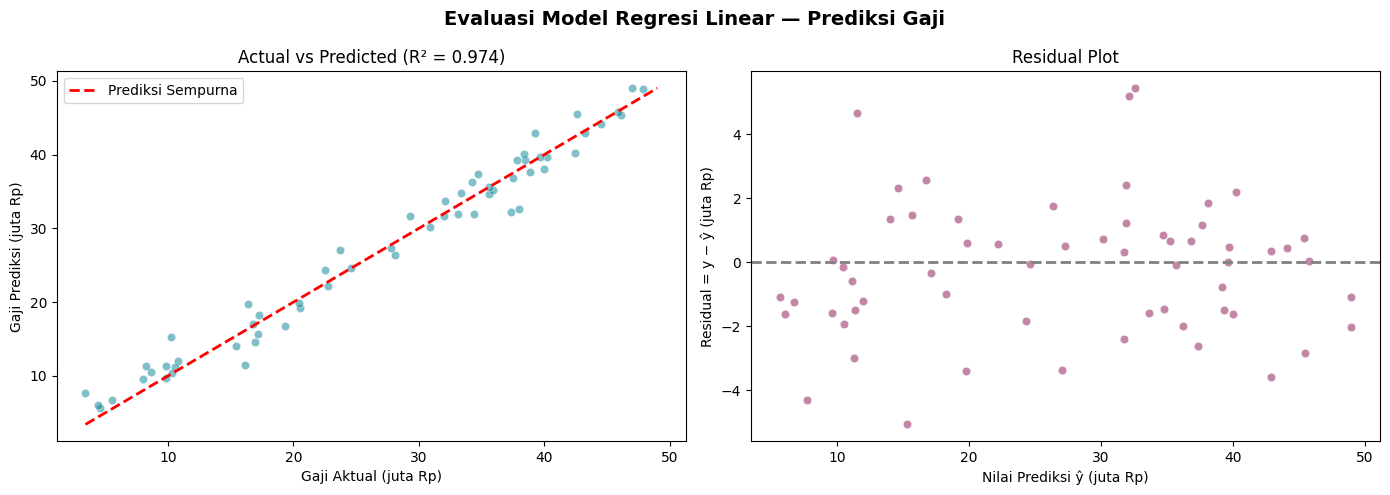

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ==================================================
# Plot 1: Actual vs Predicted
# ==================================================
axes[0].scatter(
    y_test,
    y_pred,
    alpha=0.5,
    color='#028090',
    edgecolors='white',
    lw=0.5
)

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

axes[0].plot(
    lims,
    lims,
    'r--',
    lw=2,
    label='Prediksi Sempurna'
)

axes[0].set_xlabel('Gaji Aktual (juta Rp)')
axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title(f'Actual vs Predicted (R² = {r2:.3f})')
axes[0].legend()

# ==================================================
# Plot 2: Residual Plot
# ==================================================
residuals = y_test - y_pred

axes[1].scatter(
    y_pred,
    residuals,
    alpha=0.5,
    color='#880E4F',
    edgecolors='white',
    lw=0.5
)

axes[1].axhline(
    0,
    color='gray',
    linestyle='--',
    lw=2
)

axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)')
axes[1].set_ylabel('Residual = y − ŷ (juta Rp)')
axes[1].set_title('Residual Plot')

plt.suptitle(
    'Evaluasi Model Regresi Linear — Prediksi Gaji',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    'evaluasi_regresi.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()
# Cara membaca Residual Plot:
# ✅ Baik: titik tersebar ACAK di sekitar garis y=0
# ❌ Masalah: ada pola (kurva, corong) → asumsi linearitas dilanggar

**1. Actual vs Predicted**

What?

Titik-titik pada grafik sebagian besar berada dekat dengan garis diagonal atau garis prediksi sempurna

So What?

Hal ini menunjukkan bahwa hasil prediksi model sangat mendekati nilai aktual sehingga model memiliki akurasi yang baik.

Now What?

Model dapat digunakan untuk melakukan prediksi gaji. Untuk meningkatkan performa, dapat ditambahkan variabel lain seperti usia, jabatan, sertifikasi, atau lama bekerja di perusahaan.

**2. Residual Plot**

What?

Residual tersebar secara acak di sekitar garis nol tanpa membentuk pola tertentu.

So What?

Hal ini menunjukkan bahwa asumsi linearitas model terpenuhi dan model regresi linear cocok digunakan pada dataset ini.

Now What?

Model dapat dipertahankan sebagai model dasar (baseline). Jika ingin meningkatkan akurasi, dapat dicoba metode lain seperti Regresi Polinomial, Random Forest, atau Gradient Boosting.


## **Kesimpulan**

Dari praktikum yang sudah saya lakukan, saya mempelajari bagaimana proses membangun model Machine Learning sederhana menggunakan Regresi Linear untuk memprediksi gaji berdasarkan pengalaman kerja, tingkat pendidikan, dan kota tempat bekerja. Dari hasil analisis data terlihat bahwa pengalaman kerja memiliki pengaruh yang cukup besar terhadap besarnya gaji. Selain itu, pendidikan dan lokasi kerja juga ikut memengaruhi hasil prediksi.

Setelah data diproses dan model dilatih, hasil evaluasi menunjukkan bahwa model mampu melakukan prediksi dengan cukup baik. Nilai kesalahan prediksi masih dalam batas yang wajar dan nilai R2 yang tinggi menunjukkan bahwa sebagian besar variasi gaji dapat dijelaskan oleh model yang dibuat. Grafik Actual vs Predicted juga memperlihatkan bahwa hasil prediksi sudah cukup dekat dengan nilai sebenarnya.

Dari praktikum ini, saya lebih paham bagaimana tahapan dalam Machine Learning, mulai dari pembuatan dataset, preprocessing, pelatihan model, hingga evaluasi hasil. Meskipun model yang digunakan masih sederhana, hasil yang diperoleh sudah cukup baik. Ke depannya, model dapat dikembangkan dengan menambahkan variabel lain yang lebih beragam agar prediksi yang dihasilkan menjadi lebih akurat dan mendekati kondisi di dunia nyata.
